In [ ]:
#1: Открыть датасет через пандас (Open dataset via pandas)

In [1]:
# Import pandas (it's already installed in Anaconda!)
import pandas as pd

# Load the CSV file
# IMPORTANT: Change this path to where YOUR file is located
df = pd.read_csv('sales_data.csv')

# Verify it loaded by showing the shape (rows, columns)
print(f"Dataset loaded: {df.shape[0]} rows and {df.shape[1]} columns")

Dataset loaded: 113036 rows and 18 columns


In [ ]:
#2: Показать первые и последние 5 элементов (Show first and last 5 elements)

In [2]:
# Show first 5 rows
print("FIRST 5 ROWS:")
print(df.head())
print("\n" + "="*50 + "\n")

# Show last 5 rows
print("LAST 5 ROWS:")
print(df.tail())

FIRST 5 ROWS:
         Date  Day     Month  Year  Customer_Age       Age_Group  \
0  2013-11-26   26  November  2013            19     Youth (<25)   
1  2015-11-26   26  November  2015            19     Youth (<25)   
2  2014-03-23   23     March  2014            49  Adults (35-64)   
3  2016-03-23   23     March  2016            49  Adults (35-64)   
4  2014-05-15   15       May  2014            47  Adults (35-64)   

  Customer_Gender    Country             State Product_Category Sub_Category  \
0               M     Canada  British Columbia      Accessories   Bike Racks   
1               M     Canada  British Columbia      Accessories   Bike Racks   
2               M  Australia   New South Wales      Accessories   Bike Racks   
3               M  Australia   New South Wales      Accessories   Bike Racks   
4               F  Australia   New South Wales      Accessories   Bike Racks   

               Product  Order_Quantity  Unit_Cost  Unit_Price  Profit  Cost  \
0  Hitch Rack - 4

In [ ]:
#3: Вывести информацию по дата сету и типам данных (Show info and data types)

In [3]:
# Show detailed information about the dataset
print("DATASET INFORMATION:")
print(df.info())
print("\n" + "="*50 + "\n")

# Show only the data types of each column
print("DATA TYPES:")
print(df.dtypes)

DATASET INFORMATION:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113036 entries, 0 to 113035
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Date              113036 non-null  object
 1   Day               113036 non-null  int64 
 2   Month             113036 non-null  object
 3   Year              113036 non-null  int64 
 4   Customer_Age      113036 non-null  int64 
 5   Age_Group         113036 non-null  object
 6   Customer_Gender   113036 non-null  object
 7   Country           113036 non-null  object
 8   State             113036 non-null  object
 9   Product_Category  113036 non-null  object
 10  Sub_Category      113036 non-null  object
 11  Product           113036 non-null  object
 12  Order_Quantity    113036 non-null  int64 
 13  Unit_Cost         113036 non-null  int64 
 14  Unit_Price        113036 non-null  int64 
 15  Profit            113036 non-null  int64 
 16  Cost             

In [ ]:
#4: Указать какая метрика уже есть в дата сете (Identify existing metrics)

In [4]:
# List all numerical columns (these are your metrics)
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Existing numerical metrics in this dataset:")
for col in numerical_columns:
    print(f"  - {col}")

Existing numerical metrics in this dataset:
  - Day
  - Year
  - Customer_Age
  - Order_Quantity
  - Unit_Cost
  - Unit_Price
  - Profit
  - Cost
  - Revenue


In [ ]:
#5: Для поля Order Quantity найти статистику (Statistics for Order Quantity)

In [5]:
# Get all statistics for Order Quantity
order_qty = df['Order_Quantity']

print("STATISTICS FOR 'Order_Quantity':")
print(f"  Count (number of transactions): {order_qty.count()}")
print(f"  Mean (average quantity): {order_qty.mean():.2f}")
print(f"  Minimum: {order_qty.min()}")
print(f"  Maximum: {order_qty.max()}")
print(f"  Standard Deviation: {order_qty.std():.2f}")
print(f"  Median (middle value): {order_qty.median():.2f}")

STATISTICS FOR 'Order_Quantity':
  Count (number of transactions): 113036
  Mean (average quantity): 11.90
  Minimum: 1
  Maximum: 32
  Standard Deviation: 9.56
  Median (middle value): 10.00


In [6]:
# pandas can do all of this at once!
print("\nComplete summary:")
print(order_qty.describe())


Complete summary:
count    113036.000000
mean         11.901660
std           9.561857
min           1.000000
25%           2.000000
50%          10.000000
75%          20.000000
max          32.000000
Name: Order_Quantity, dtype: float64


In [ ]:
#6: Для поля Order Quantity построить гистограмму (Histogram for Order Quantity)

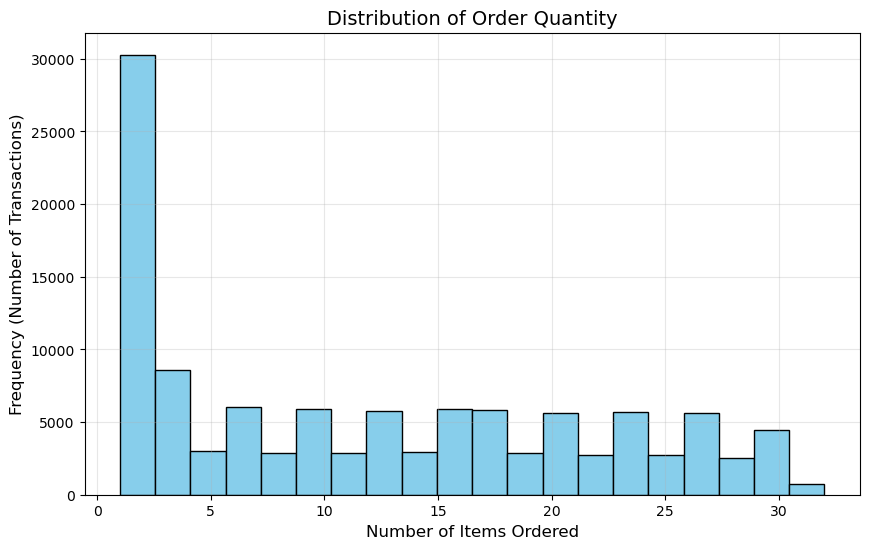

In [8]:
import matplotlib.pyplot as plt

# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(df['Order_Quantity'], bins=20, edgecolor='black', color='skyblue')

# Add labels and title
plt.title('Distribution of Order Quantity', fontsize=14)
plt.xlabel('Number of Items Ordered', fontsize=12)
plt.ylabel('Frequency (Number of Transactions)', fontsize=12)
plt.grid(True, alpha=0.3)

# Show the plot
plt.show()

In [ ]:
#7: Посчитать количество продуктов каждого типа и круговую диаграмму (Count products by type and pie chart)

PRODUCT CATEGORY COUNTS:
Product_Category
Accessories    70120
Bikes          25982
Clothing       16934
Name: count, dtype: int64


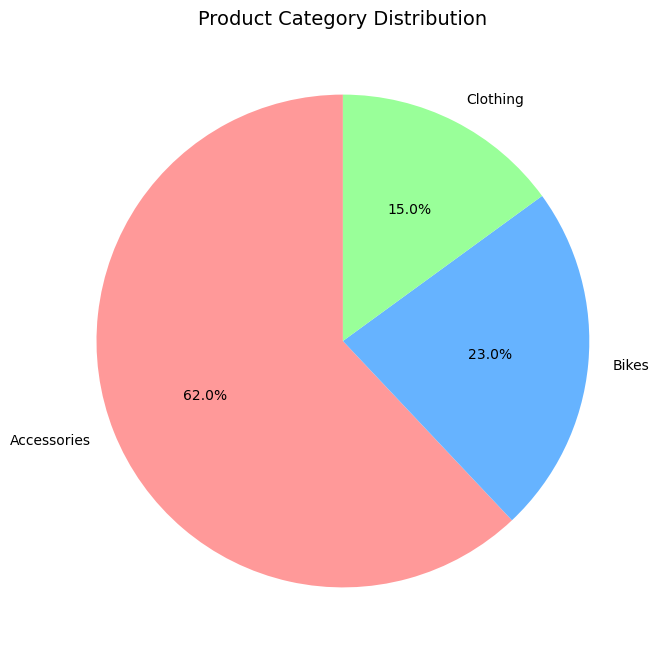

In [9]:
# Count how many of each product category
product_counts = df['Product_Category'].value_counts()

print("PRODUCT CATEGORY COUNTS:")
print(product_counts)

# Create pie chart
plt.figure(figsize=(8, 8))
plt.pie(product_counts.values, labels=product_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=['#ff9999','#66b3ff','#99ff99','#ffcc99'])

plt.title('Product Category Distribution', fontsize=14)
plt.show()

In [ ]:
#8: Вывести все локации, где происходила продажа (Show all locations - country and state)

In [10]:
# Show unique countries
print("COUNTRIES WHERE SALES OCCURRED:")
print(df['Country'].unique())
print(f"\nTotal unique countries: {df['Country'].nunique()}\n")

# Show unique state/province combinations
print("STATES/PROVINCES WHERE SALES OCCURRED:")
print(df['State'].unique())
print(f"\nTotal unique states: {df['State'].nunique()}\n")

# Better: Show country-state pairs
print("COUNTRY - STATE PAIRS:")
country_state_pairs = df[['Country', 'State']].drop_duplicates().sort_values(['Country', 'State'])
print(country_state_pairs.to_string(index=False))

COUNTRIES WHERE SALES OCCURRED:
['Canada' 'Australia' 'United States' 'Germany' 'France' 'United Kingdom']

Total unique countries: 6

STATES/PROVINCES WHERE SALES OCCURRED:
['British Columbia' 'New South Wales' 'Victoria' 'Oregon' 'California'
 'Saarland' 'Seine Saint Denis' 'Moselle' 'Queensland' 'England' 'Nord'
 'Washington' 'Hessen' 'Nordrhein-Westfalen' 'Hamburg' 'Loir et Cher'
 'Kentucky' 'Seine (Paris)' 'South Australia' 'Loiret' 'Alberta' 'Bayern'
 'Hauts de Seine' 'Yveline' 'Essonne' "Val d'Oise" 'Tasmania'
 'Seine et Marne' 'Val de Marne' 'Pas de Calais' 'Charente-Maritime'
 'Garonne (Haute)' 'Brandenburg' 'Texas' 'New York' 'Florida' 'Somme'
 'Illinois' 'South Carolina' 'North Carolina' 'Georgia' 'Virginia' 'Ohio'
 'Ontario' 'Wyoming' 'Missouri' 'Montana' 'Utah' 'Minnesota' 'Mississippi'
 'Massachusetts' 'Arizona' 'Alabama']

Total unique states: 53

COUNTRY - STATE PAIRS:
       Country               State
     Australia     New South Wales
     Australia          Queensla

In [ ]:
#9: Вывести все продукты компании (Show all company products)

In [11]:
# Show all unique product names
print("ALL PRODUCTS SOLD BY THE COMPANY:")
products = df['Product'].unique()
for i, product in enumerate(products, 1):
    print(f"{i:3}. {product}")

print(f"\nTotal unique products: {len(products)}")

ALL PRODUCTS SOLD BY THE COMPANY:
  1. Hitch Rack - 4-Bike
  2. All-Purpose Bike Stand
  3. Mountain Bottle Cage
  4. Water Bottle - 30 oz.
  5. Road Bottle Cage
  6. AWC Logo Cap
  7. Bike Wash - Dissolver
  8. Fender Set - Mountain
  9. Half-Finger Gloves, L
 10. Half-Finger Gloves, M
 11. Half-Finger Gloves, S
 12. Sport-100 Helmet, Black
 13. Sport-100 Helmet, Red
 14. Sport-100 Helmet, Blue
 15. Hydration Pack - 70 oz.
 16. Short-Sleeve Classic Jersey, XL
 17. Short-Sleeve Classic Jersey, L
 18. Short-Sleeve Classic Jersey, M
 19. Short-Sleeve Classic Jersey, S
 20. Long-Sleeve Logo Jersey, M
 21. Long-Sleeve Logo Jersey, XL
 22. Long-Sleeve Logo Jersey, L
 23. Long-Sleeve Logo Jersey, S
 24. Mountain-100 Silver, 38
 25. Mountain-100 Silver, 44
 26. Mountain-100 Black, 48
 27. Mountain-100 Silver, 48
 28. Mountain-100 Black, 38
 29. Mountain-200 Silver, 38
 30. Mountain-100 Black, 44
 31. Mountain-100 Silver, 42
 32. Mountain-200 Black, 46
 33. Mountain-200 Silver, 42
 34. Mountai

In [ ]:
#If you want to see products by category:

In [12]:
print("\nPRODUCTS BY CATEGORY:")
for category in df['Product_Category'].unique():
    print(f"\n{category.upper()}:")
    category_products = df[df['Product_Category'] == category]['Product'].unique()
    for product in category_products:
        print(f"  - {product}")


PRODUCTS BY CATEGORY:

ACCESSORIES:
  - Hitch Rack - 4-Bike
  - All-Purpose Bike Stand
  - Mountain Bottle Cage
  - Water Bottle - 30 oz.
  - Road Bottle Cage
  - AWC Logo Cap
  - Bike Wash - Dissolver
  - Fender Set - Mountain
  - Sport-100 Helmet, Black
  - Sport-100 Helmet, Red
  - Sport-100 Helmet, Blue
  - Hydration Pack - 70 oz.
  - Mountain Tire Tube
  - Touring Tire Tube
  - Patch Kit/8 Patches
  - HL Mountain Tire
  - LL Mountain Tire
  - Road Tire Tube
  - LL Road Tire
  - Touring Tire
  - ML Mountain Tire
  - HL Road Tire
  - ML Road Tire

CLOTHING:
  - Water Bottle - 30 oz.
  - AWC Logo Cap
  - Fender Set - Mountain
  - Half-Finger Gloves, L
  - Half-Finger Gloves, M
  - Half-Finger Gloves, S
  - Short-Sleeve Classic Jersey, XL
  - Short-Sleeve Classic Jersey, L
  - Short-Sleeve Classic Jersey, M
  - Short-Sleeve Classic Jersey, S
  - Long-Sleeve Logo Jersey, M
  - Long-Sleeve Logo Jersey, XL
  - Long-Sleeve Logo Jersey, L
  - Long-Sleeve Logo Jersey, S
  - Women's Mountai

In [13]:
#10: Столбчатая диаграмма 10 самых продаваемых продуктов (Bar chart - Top 10 best-selling products)

TOP 10 PRODUCTS BY UNITS SOLD:
Product
Water Bottle - 30 oz.      164086
Patch Kit/8 Patches        157583
Mountain Tire Tube         102792
AWC Logo Cap                67316
Sport-100 Helmet, Red       63663
Road Tire Tube              62296
Fender Set - Mountain       62118
Sport-100 Helmet, Black     62105
Touring Tire Tube           56802
Sport-100 Helmet, Blue      55895
Name: Order_Quantity, dtype: int64


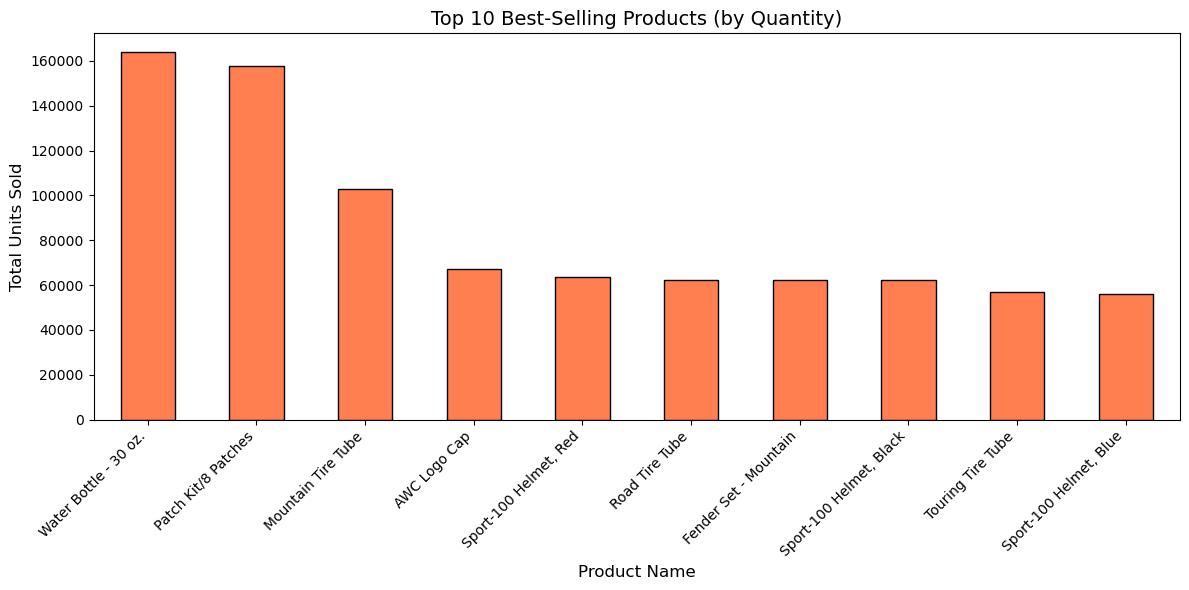

In [14]:
# Sum quantities by product
product_sales = df.groupby('Product')['Order_Quantity'].sum().sort_values(ascending=False).head(10)

print("TOP 10 PRODUCTS BY UNITS SOLD:")
print(product_sales)

# Create bar chart
plt.figure(figsize=(12, 6))
product_sales.plot(kind='bar', color='coral', edgecolor='black')

plt.title('Top 10 Best-Selling Products (by Quantity)', fontsize=14)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Total Units Sold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
#Option B: By revenue generated (most money)

TOP 10 PRODUCTS BY REVENUE GENERATED:
Product
Road-150 Red, 62           3829416
Mountain-200 Black, 38     3366248
Road-150 Red, 52           3180840
Road-150 Red, 56           3158805
Mountain-200 Silver, 42    3081078
Mountain-200 Silver, 38    3035442
Road-150 Red, 48           2965309
Mountain-200 Black, 46     2769620
Mountain-200 Black, 42     2641606
Mountain-200 Silver, 46    2376146
Name: Revenue, dtype: int64


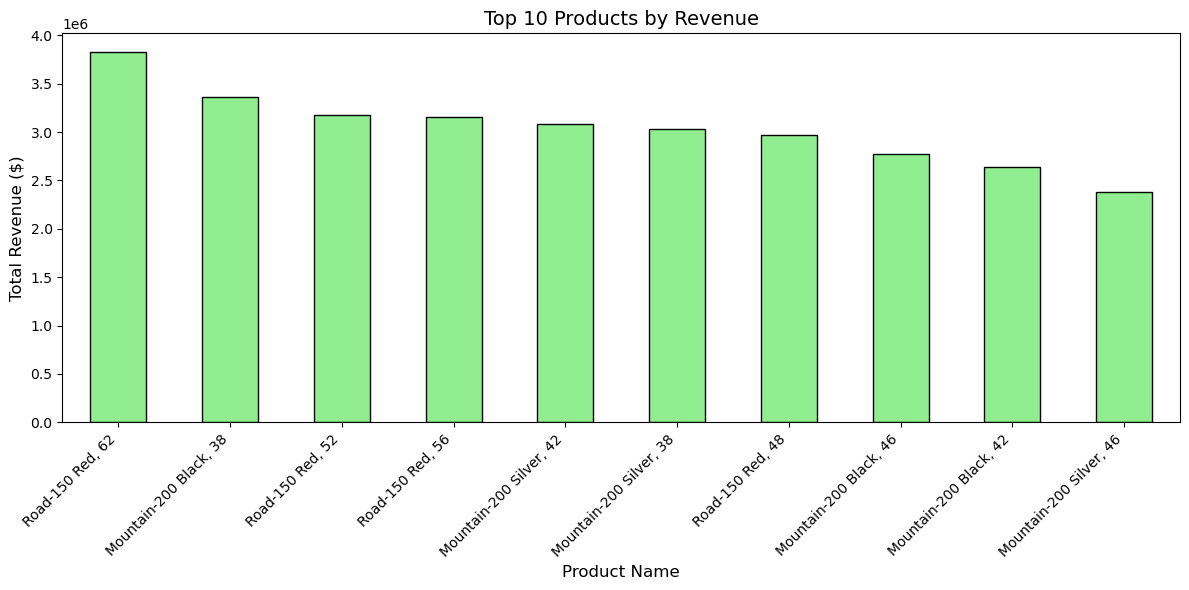

In [15]:
# Sum revenue by product
product_revenue = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False).head(10)

print("TOP 10 PRODUCTS BY REVENUE GENERATED:")
print(product_revenue)

# Create bar chart
plt.figure(figsize=(12, 6))
product_revenue.plot(kind='bar', color='lightgreen', edgecolor='black')

plt.title('Top 10 Products by Revenue', fontsize=14)
plt.xlabel('Product Name', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()